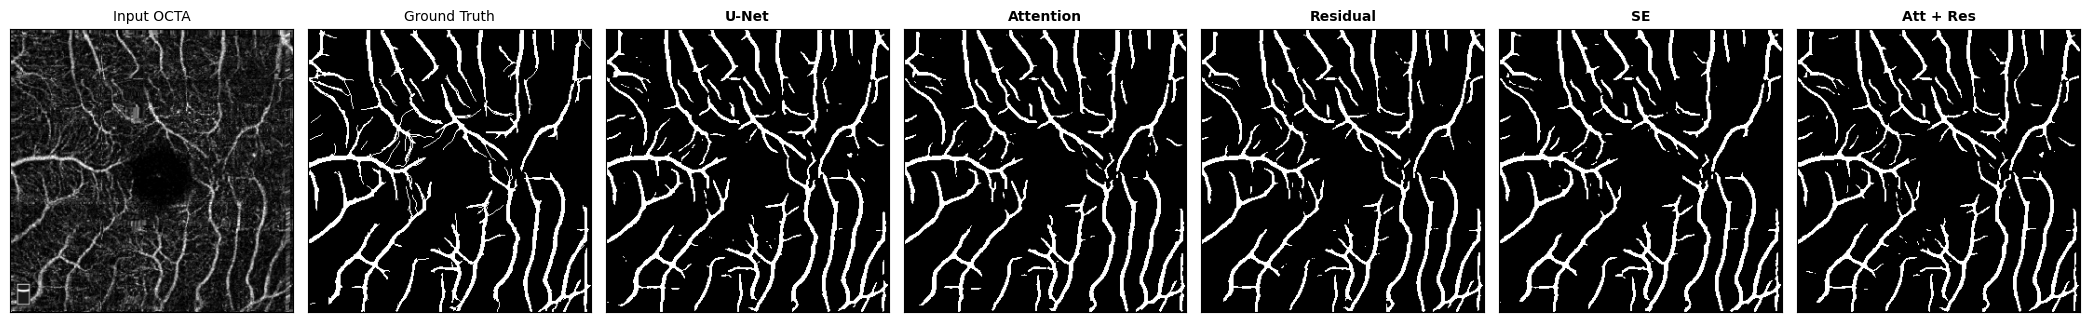

In [3]:
import sys
sys.path.append('/users/egottfri/code/octa-segmentation/src')

import glob
import torch
import numpy as np
import matplotlib.pyplot as plt

from model import build_model
from dataset import get_kfold_splits, create_datasets

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# ---- Rebuild raw test set ----
raw_root = '/files22_lrsresearch/ENG_Lee-Lab_Shared/group/data/public/rose_dataset/ROSE-1/SVC'
raw_train_imgs = sorted(glob.glob(f'{raw_root}/train/img/*'))
raw_train_masks = sorted(glob.glob(f'{raw_root}/train/gt/*'))
raw_test_imgs = sorted(glob.glob(f'{raw_root}/test/img/*'))
raw_test_masks = sorted(glob.glob(f'{raw_root}/test/gt/*'))

raw_splits = get_kfold_splits(raw_train_imgs, raw_train_masks, raw_test_imgs, raw_test_masks)
_, _, test_dataset = create_datasets(raw_splits['folds'][0], raw_splits['test'])

img_tensor, gt_tensor = test_dataset[0]
img_np = img_tensor.squeeze().cpu().numpy() if torch.is_tensor(img_tensor) else np.array(img_tensor).squeeze()
gt_np = gt_tensor.squeeze().cpu().numpy() if torch.is_tensor(gt_tensor) else np.array(gt_tensor).squeeze()

# ---- Checkpoint paths for each variant ----
checkpoint_paths = {
    'U-Net':      '../../results/rose1_ablation/raw/unet/best_model_fold1.pth',
    'Attention':  '../../results/rose1_ablation/raw/attention_unet/best_model_fold1.pth',
    'Residual':   '../../results/rose1_ablation/raw/res_unet/best_model_fold1.pth',
    'SE':         '../../results/rose1_ablation/raw/se_unet/best_model_fold1.pth',
    'Att + Res':  '../../results/rose1_ablation/raw/att_res_unet/best_model_fold1.pth',
}

model_names = {
    'U-Net': 'unet',
    'Attention': 'attention_unet',
    'Residual': 'res_unet',
    'SE': 'se_unet',
    'Att + Res': 'att_res_unet',
}

# ---- Handles both old (bare state_dict) and new ({model_name, model_kwargs, state_dict}) formats ----
def remap_old_state_dict(old_sd):
    new_sd = {}
    for k, v in old_sd.items():
        if '.double_conv.' in k and not k.startswith(('up', 'final')):
            prefix, rest = k.split('.double_conv.', 1)
            new_sd[f'{prefix}.conv.double_conv.{rest}'] = v
        else:
            new_sd[k] = v
    return new_sd

def load_model(ckpt_path, fallback_name):
    ckpt = torch.load(ckpt_path, map_location=device)
    if isinstance(ckpt, dict) and 'state_dict' in ckpt:
        # new format: trust the checkpoint's own model_name/model_kwargs
        model = build_model(ckpt.get('model_name', fallback_name), **ckpt.get('model_kwargs', {}))
        model.load_state_dict(ckpt['state_dict'])
    else:
        # old format: bare state_dict, predates ConvBlock refactor, needs key remap
        model = build_model(fallback_name)
        model.load_state_dict(remap_old_state_dict(ckpt))
    model.to(device).eval()
    return model

# ---- Load all 5 models and predict ----
def predict(model, img):
    with torch.no_grad():
        inp = img.unsqueeze(0).to(device)
        pred = torch.sigmoid(model(inp)).squeeze().cpu().numpy()
        return (pred > 0.5).astype(float)

predictions = {}
for label, path in checkpoint_paths.items():
    model = load_model(path, model_names[label])
    predictions[label] = predict(model, img_tensor)

# ---- Plot: Input, GT, then all 5 predictions ----
labels = ['Input OCTA', 'Ground Truth'] + list(predictions.keys())
panels = [img_np, gt_np] + list(predictions.values())

fig, axes = plt.subplots(1, len(panels), figsize=(3 * len(panels), 3.5))
for ax, panel, label in zip(axes, panels, labels):
    ax.imshow(panel, cmap='gray')
    ax.set_title(label, fontsize=10, fontweight='bold' if label not in ('Input OCTA', 'Ground Truth') else 'normal')
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.savefig('../figures/flexunet_variant_comparison.png', dpi=300, bbox_inches='tight')
plt.show()